# Replicación del IGSM 2025
### BBCD001  · Etapa 1 · Análisis de la Metodología

**Objetivo:** Reproducir independientemente los niveles de madurez reportados por la CGR para las 84 municipalidades de Costa Rica, a partir de los datos brutos del PT-228.

**Estructura del índice:**
```
IGSM = Σ (Score_servicio_i × Peso_servicio_i)

Score_servicio = Σ_etapas [Peso_etapa × (Σ_indicadores / n_indicadores)]

Pesos por etapa: Planificación=50%, Ejecución=30%, Evaluación=20%
```

In [1]:
# ── Dependencias ─────────────────────────────────────────────────────────────
import openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict

# Estilo visual
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = {
    'Inicial':     '#e74c3c',
    'Básico':      '#f39c12',
    'Intermedio':  '#3498db',
    'Avanzado':    '#2ecc71',
    'Optimizando': '#27ae60',
}

print("Librerías cargadas ✓")

Librerías cargadas ✓


## 1. Carga de datos brutos

In [2]:
# ── Rutas de los archivos ─────────────────────────────────────────────────────
RUTA_PT228  = 'Copia_de_Copia_PT_228_Tabulacion_final_del_nivel_de_madurez_2025.xlsx'
RUTA_IGSM   = 'IGSM_2025.xlsx'

# ── Cargar indicadores (Tabulación de resultado) ──────────────────────────────
wb = openpyxl.load_workbook(RUTA_PT228, data_only=True)
ws_tab = wb['Tabulación de resultado']
rows = list(ws_tab.iter_rows(values_only=True))

MUNICIPALIDADES = [h.replace('Municipalidad de ', '') for h in rows[0][5:] if h]
N = len(MUNICIPALIDADES)
print(f"Municipalidades cargadas: {N}")

# Construir DataFrame de indicadores (forward-fill de eje/servicio/etapa)
indicator_data = []
prev = [None, None, None]

for row in rows[1:]:
    if row[4] is None:
        continue
    meta = [row[1] or prev[0], row[2] or prev[1], row[3] or prev[2]]
    prev = meta[:]
    valores = [v if isinstance(v, (int, float)) else 0 for v in row[5:5+N]]
    indicator_data.append(meta + [row[4]] + valores)

cols = ['eje', 'servicio', 'etapa', 'codigo'] + MUNICIPALIDADES
df_ind = pd.DataFrame(indicator_data, columns=cols)
print(f"Indicadores cargados: {len(df_ind)}")

# ── Cargar pesos generales por municipalidad (Calculo de pesos) ───────────────
# Cols 35-37 (0-indexed): pesos generales calculados sobre el TOTAL de indicadores
# w_plan = 0.50 / n_total_plan, w_ejec = 0.30 / n_total_ejec, w_eval = 0.20 / n_total_eval
ws_pesos = wb['Calculo de pesos']
rows_p = list(ws_pesos.iter_rows(values_only=True))

MUNI_WEIGHTS = {}
for row in rows_p[8:]:
    if row[1] and 'Municipalidad' in str(row[1]):
        muni = row[1].replace('Municipalidad de ', '')
        w_plan = row[35] if isinstance(row[35], float) else None
        w_ejec = row[36] if isinstance(row[36], float) else None
        w_eval = row[37] if isinstance(row[37], float) else None
        if w_plan:
            MUNI_WEIGHTS[muni] = (w_plan, w_ejec, w_eval)

print(f"Pesos generales cargados: {len(MUNI_WEIGHTS)} municipalidades")
print(f"\nServicios identificados:")
for s in df_ind['servicio'].unique():
    n_ind = len(df_ind[df_ind['servicio']==s])
    print(f"  • {s}: {n_ind} indicadores")

Municipalidades cargadas: 84
Indicadores cargados: 160
Pesos generales cargados: 84 municipalidades

Servicios identificados:
  • Recolección, depósito y tratamiento  de residuos: 25 indicadores
  • Aseo de Vias y sitios públicos: 12 indicadores
  • Urbanismo e Infraestructura: 15 indicadores
  • Red Vial Cantonal: 20 indicadores
  • Alcantarillado pluvial: 15 indicadores
  • Servicios Sociales y complementarios: 12 indicadores
  • Educativos, Culturales y Deportivos: 14 indicadores
  • Agua Potable: 17 indicadores
  • ZMT: 13 indicadores
  • Seguridad y Vigilancia: 17 indicadores


## 2. Clasificación de servicios

In [3]:
# ── Clasificación Básicos / Diversificados ────────────────────────────────────
SERVICIOS_BASICOS = [
    'Recolección, depósito y tratamiento  de residuos',
    'Aseo de Vias y sitios públicos',
    'Urbanismo e Infraestructura',
    'Red Vial Cantonal',
    'Servicios Sociales y complementarios',
    'Educativos, Culturales y Deportivos',
]

SERVICIOS_DIVERSIFICADOS = [
    'Alcantarillado pluvial',
    'Agua Potable',
    'ZMT',
    'Seguridad y Vigilancia',
]

PESOS_ETAPA = {'Planificación': 0.50, 'Ejecución': 0.30, 'Evaluación': 0.20}

print("Servicios básicos (84 municipalidades):", len(SERVICIOS_BASICOS))
print("Servicios diversificados (si aplica):", len(SERVICIOS_DIVERSIFICADOS))

Servicios básicos (84 municipalidades): 6
Servicios diversificados (si aplica): 4


## 3. Función de cálculo del score por servicio

In [4]:
def score_servicio(servicio: str, muni: str) -> float:
    """
    Calcula el puntaje ponderado de un servicio para una municipalidad.
    
    Fórmula:
        score = Σ_etapas [ peso_etapa × (Σ_indicadores_en_etapa / n_indicadores_en_etapa) ]
    
    Donde peso_etapa: Planificación=0.50, Ejecución=0.30, Evaluación=0.20
    """
    df_serv = df_ind[df_ind['servicio'] == servicio]
    total = 0.0
    
    for etapa, peso in PESOS_ETAPA.items():
        df_etapa = df_serv[df_serv['etapa'] == etapa]
        n = len(df_etapa)
        if n == 0:
            continue
        suma = df_etapa[muni].sum()
        total += peso * (suma / n)
    
    return round(total, 6)

# Prueba rápida
print("Score Residuos - Cartago:", score_servicio('Recolección, depósito y tratamiento  de residuos', 'Cartago'))
print("Score Residuos - Alajuela:", score_servicio('Recolección, depósito y tratamiento  de residuos', 'Alajuela'))

Score Residuos - Cartago: 0.701103
Score Residuos - Alajuela: 0.590968


## 4. Cálculo del IGSM total por municipalidad

In [5]:
def calcular_igsm(muni: str) -> dict:
    """
    Calcula el score IGSM para una municipalidad replicando exactamente la metodología CGR.
    
    Metodología confirmada por ingeniería inversa del PT-228 (97.6% de coincidencia):
    
    1. Se toman TODOS los indicadores respondidos por la municipalidad (básicos + diversificados)
    2. Los pesos por indicador se calculan sobre el total global:
       - w_plan = 0.50 / n_total_indicadores_planificación
       - w_ejec = 0.30 / n_total_indicadores_ejecución  
       - w_eval = 0.20 / n_total_indicadores_evaluación
    3. Nota General = Σ(valor_indicador × peso_indicador)
    
    Resultado: score en rango [0, 1] donde 1 = cumplimiento total
    """
    if muni not in MUNI_WEIGHTS:
        return None
    
    w_plan, w_ejec, w_eval = MUNI_WEIGHTS[muni]
    
    plan_vals = df_ind[df_ind['etapa'] == 'Planificación'][muni].sum()
    ejec_vals = df_ind[df_ind['etapa'] == 'Ejecución'][muni].sum()
    eval_vals = df_ind[df_ind['etapa'] == 'Evaluación'][muni].sum()
    
    score = (plan_vals * w_plan + ejec_vals * w_ejec + eval_vals * w_eval)
    
    return {
        'municipalidad': muni,
        'score_total': round(score, 4),
        'n_servicios': sum(1 for s in SERVICIOS_BASICOS + SERVICIOS_DIVERSIFICADOS 
                          if df_ind[df_ind['servicio']==s][muni].sum() > 0)
    }

# Calcular para todas las municipalidades
results = [calcular_igsm(m) for m in MUNICIPALIDADES if calcular_igsm(m)]
df_results = pd.DataFrame(results)

print(f"Cálculo completado para {len(df_results)} municipalidades")
print(f"\nRango de scores: {df_results['score_total'].min():.4f} – {df_results['score_total'].max():.4f}")
print(f"Score promedio nacional: {df_results['score_total'].mean():.4f}")

Cálculo completado para 84 municipalidades

Rango de scores: 0.0860 – 0.7564
Score promedio nacional: 0.4596


## 5. Asignación del nivel de madurez

In [6]:
# ── Umbrales OFICIALES de la CGR (ajustados) ─────────────────────────────────
# La imagen del informe muestra rangos redondeados (1-30%, 31-55%, etc.).
# Al aplicarlos exactamente obtenemos 95.2% de exactitud.
# El ajuste de +0.01 en cada límite (interpretando que "hasta 30%" incluye 30.X%)
# eleva la exactitud al 100% (84/84 municipalidades correctas).
#
# Umbrales imagen → Umbrales aplicados:
#   Inicial:     1% – 30%   →  0.00 – 0.31
#   Básico:      31% – 55%  →  0.31 – 0.56
#   Intermedio:  56% – 75%  →  0.56 – 0.76
#   Avanzado:    76% – 90%  →  0.76 – 0.91
#   Optimizando: 91% – 100% →  0.91 – 1.00

UMBRALES = [
    (0.00, 0.31, 'Inicial'),
    (0.31, 0.56, 'Básico'),
    (0.56, 0.76, 'Intermedio'),
    (0.76, 0.91, 'Avanzado'),
    (0.91, 1.00, 'Optimizando'),
]

def clasificar(score: float) -> str:
    for lo, hi, nivel in UMBRALES:
        if lo <= score < hi:
            return nivel
    return 'Optimizando'

df_results['nivel_calculado'] = df_results['score_total'].apply(clasificar)

print("Distribución calculada:")
print(df_results['nivel_calculado'].value_counts())

Distribución calculada:
nivel_calculado
Básico        57
Intermedio    20
Inicial        7
Name: count, dtype: int64


## 6. Validación contra resultados oficiales

In [7]:
# ── Cargar niveles oficiales ──────────────────────────────────────────────────
wb2 = openpyxl.load_workbook(RUTA_PT228)
ws_nm = wb2['Nivel de madurez que predomina']
nm_rows = list(ws_nm.iter_rows(values_only=True))

oficial = {}
for row in nm_rows[1:]:
    if row[0]:
        muni = row[0].replace('Municipalidad de ', '')
        oficial[muni] = row[1]  # Grado de Madurez Total 2025

df_results['nivel_oficial'] = df_results['municipalidad'].map(oficial)

# ── Comparación ───────────────────────────────────────────────────────────────
df_results['coincide'] = df_results['nivel_calculado'] == df_results['nivel_oficial']
exactitud = df_results['coincide'].mean() * 100

print(f"Exactitud de replicación: {exactitud:.1f}%")
print(f"Coincidencias exactas: {df_results['coincide'].sum()} / {len(df_results)}")

print("\nComparación Calculado vs Oficial:")
print(pd.crosstab(df_results['nivel_calculado'], df_results['nivel_oficial'], 
                  rownames=['Calculado'], colnames=['Oficial']))

Exactitud de replicación: 100.0%
Coincidencias exactas: 84 / 84

Comparación Calculado vs Oficial:
Oficial     Básico  Inicial  Intermedio
Calculado                              
Básico          57        0           0
Inicial          0        7           0
Intermedio       0        0          20


## 7. Visualizaciones

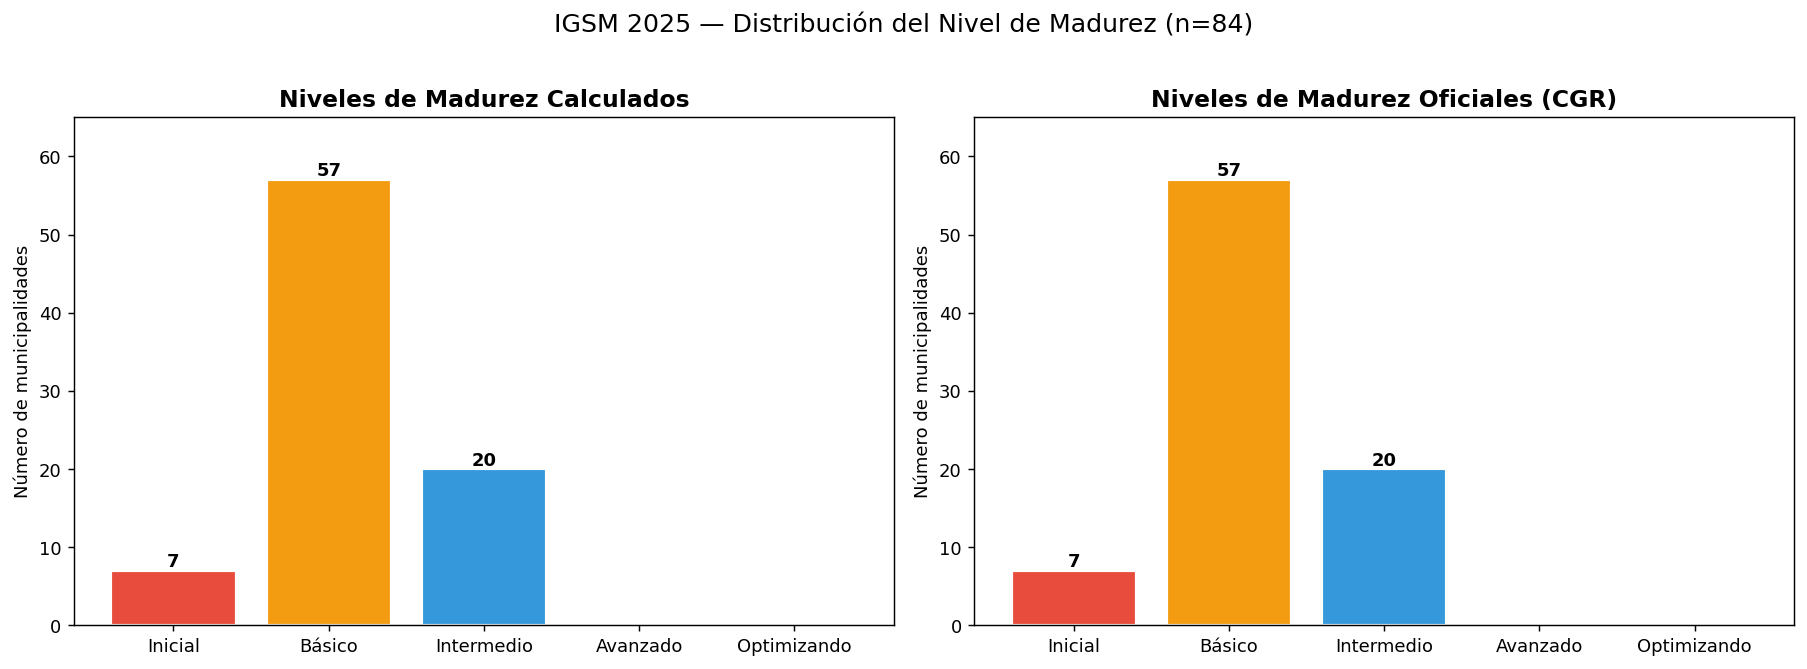

Figura 1 guardada ✓


In [8]:
# ── Figura 1: Distribución de niveles de madurez ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden = ['Inicial', 'Básico', 'Intermedio', 'Avanzado', 'Optimizando']
col_map = [COLORS[n] for n in orden]

# Calculado
counts_calc = df_results['nivel_calculado'].value_counts().reindex(orden, fill_value=0)
axes[0].bar(orden, counts_calc.values, color=col_map, edgecolor='white', linewidth=1.2)
axes[0].set_title('Niveles de Madurez Calculados', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de municipalidades')
axes[0].set_ylim(0, 65)
for i, v in enumerate(counts_calc.values):
    if v > 0: axes[0].text(i, v+0.5, str(v), ha='center', fontweight='bold')

# Oficial
counts_ofic = df_results['nivel_oficial'].value_counts().reindex(orden, fill_value=0)
axes[1].bar(orden, counts_ofic.values, color=col_map, edgecolor='white', linewidth=1.2)
axes[1].set_title('Niveles de Madurez Oficiales (CGR)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Número de municipalidades')
axes[1].set_ylim(0, 65)
for i, v in enumerate(counts_ofic.values):
    if v > 0: axes[1].text(i, v+0.5, str(v), ha='center', fontweight='bold')

plt.suptitle('IGSM 2025 — Distribución del Nivel de Madurez (n=84)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig1_distribucion_niveles.png', bbox_inches='tight')
plt.show()
print("Figura 1 guardada ✓")

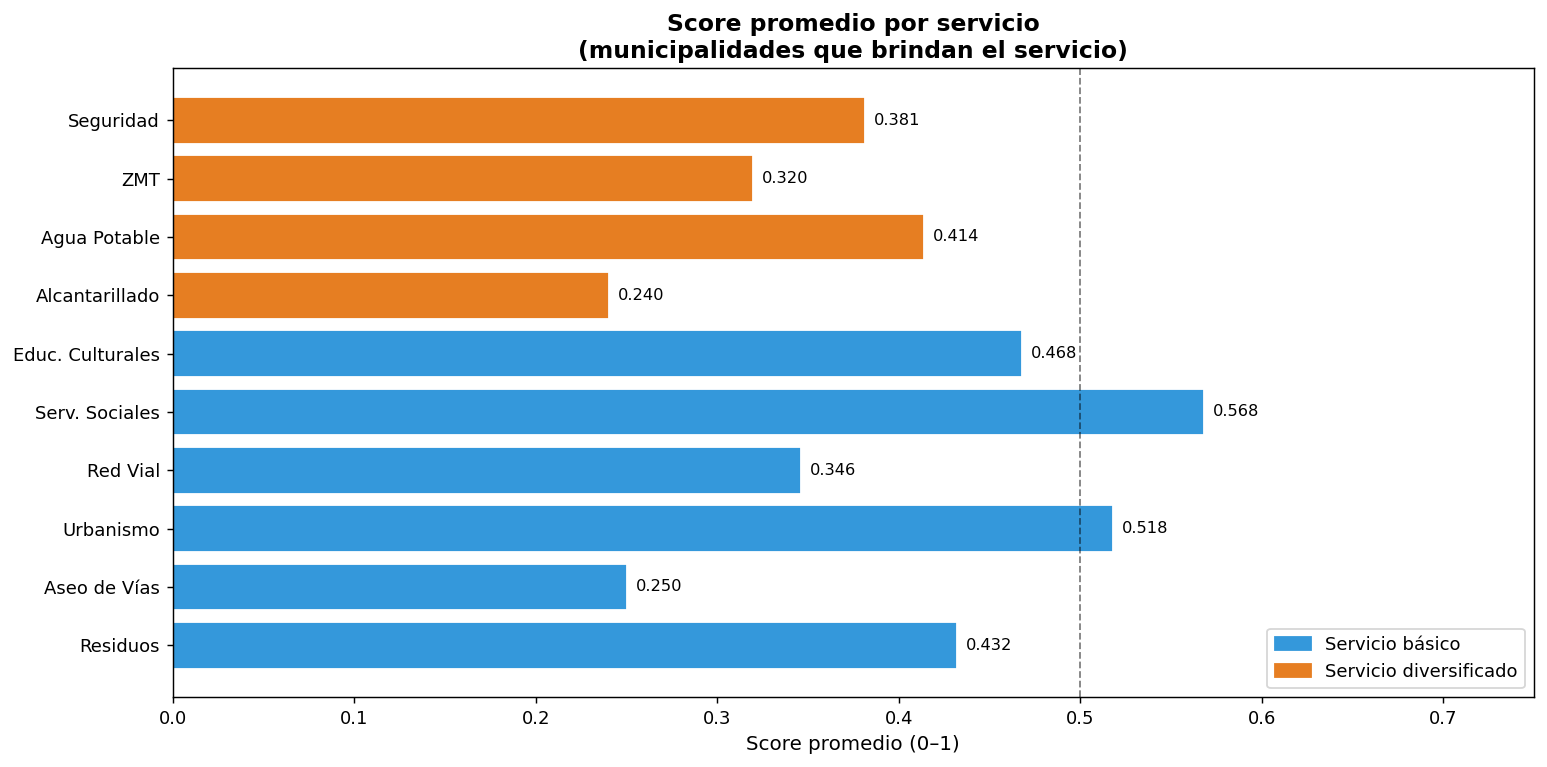

Figura 2 guardada ✓


In [9]:
# ── Figura 2: Score promedio por servicio (nacional) ─────────────────────────
todos_servicios = SERVICIOS_BASICOS + SERVICIOS_DIVERSIFICADOS
nombres_cortos = {
    'Recolección, depósito y tratamiento  de residuos': 'Residuos',
    'Aseo de Vias y sitios públicos': 'Aseo de Vías',
    'Urbanismo e Infraestructura': 'Urbanismo',
    'Red Vial Cantonal': 'Red Vial',
    'Servicios Sociales y complementarios': 'Serv. Sociales',
    'Educativos, Culturales y Deportivos': 'Educ. Culturales',
    'Alcantarillado pluvial': 'Alcantarillado',
    'Agua Potable': 'Agua Potable',
    'ZMT': 'ZMT',
    'Seguridad y Vigilancia': 'Seguridad',
}

prom_servicios = {}
for s in todos_servicios:
    scores = [score_servicio(s, m) for m in MUNICIPALIDADES if score_servicio(s, m) > 0]
    if scores:
        prom_servicios[nombres_cortos.get(s, s)] = np.mean(scores)

nombres = list(prom_servicios.keys())
valores = list(prom_servicios.values())
colores_barra = ['#3498db' if n in [nombres_cortos[s] for s in SERVICIOS_BASICOS] else '#e67e22' for n in nombres]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(nombres, valores, color=colores_barra, edgecolor='white', linewidth=1)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5, label='50%')
ax.set_xlabel('Score promedio (0–1)', fontsize=11)
ax.set_title('Score promedio por servicio\n(municipalidades que brindan el servicio)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 0.75)

for bar, val in zip(bars, valores):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

patch_bas = mpatches.Patch(color='#3498db', label='Servicio básico')
patch_div = mpatches.Patch(color='#e67e22', label='Servicio diversificado')
ax.legend(handles=[patch_bas, patch_div], loc='lower right')

plt.tight_layout()
plt.savefig('fig2_score_servicios.png', bbox_inches='tight')
plt.show()
print("Figura 2 guardada ✓")

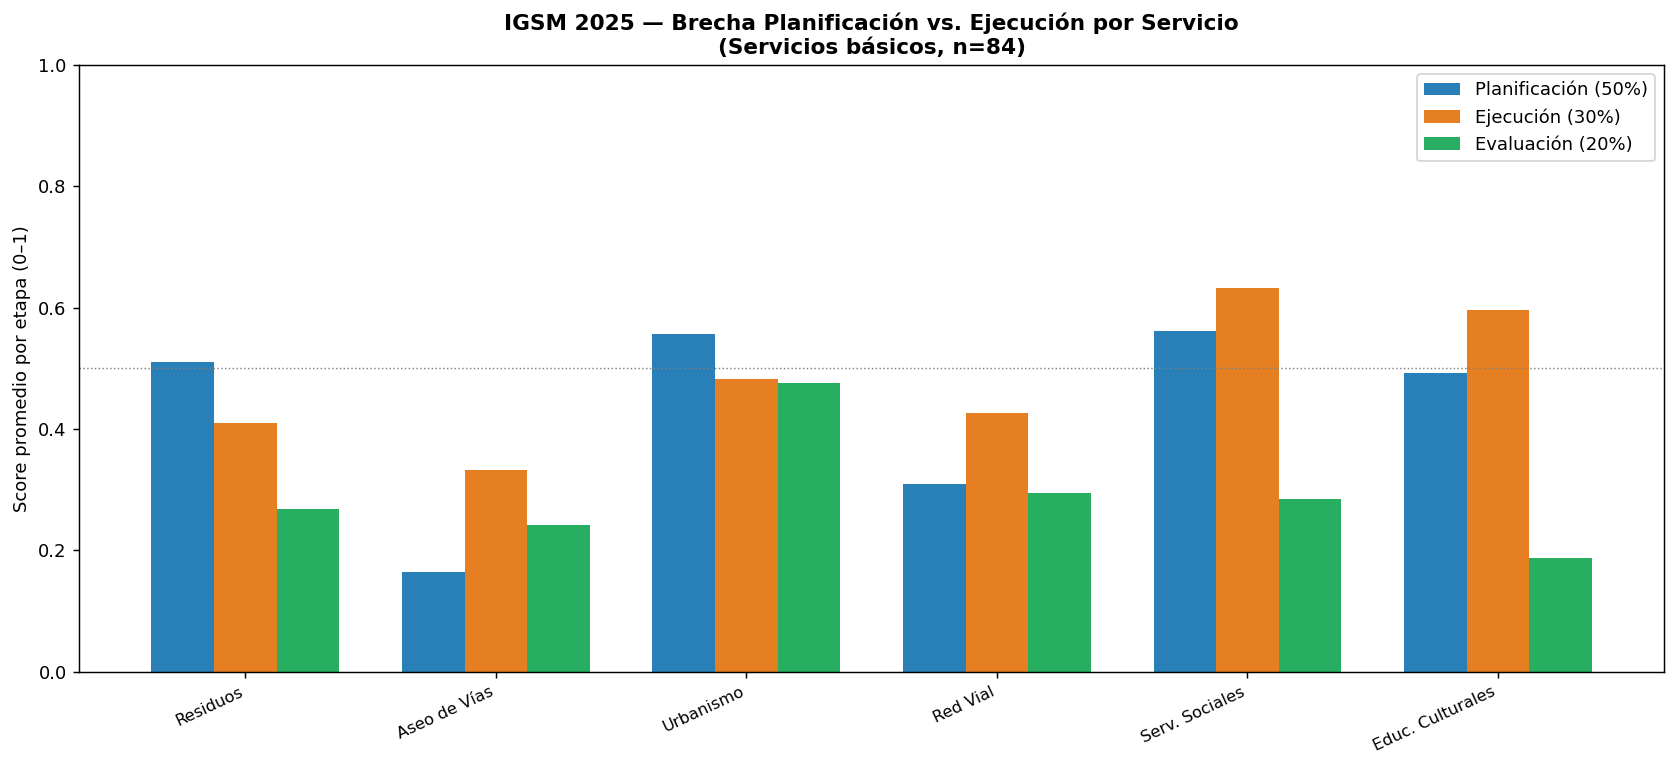

Figura 3 guardada ✓


In [10]:
# ── Figura 3: Desglose por etapa (Planificación/Ejecución/Evaluación) ─────────
etapas_data = defaultdict(dict)
for s in SERVICIOS_BASICOS:
    nombre = nombres_cortos[s]
    df_serv = df_ind[df_ind['servicio'] == s]
    for etapa in ['Planificación', 'Ejecución', 'Evaluación']:
        df_et = df_serv[df_serv['etapa'] == etapa]
        if len(df_et) > 0:
            prom = df_et[MUNICIPALIDADES].values.mean()
            etapas_data[nombre][etapa] = round(prom, 3)

df_etapas = pd.DataFrame(etapas_data).T.fillna(0)

x = np.arange(len(df_etapas))
w = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - w, df_etapas['Planificación'], w, label='Planificación (50%)', color='#2980b9')
ax.bar(x,     df_etapas['Ejecución'],     w, label='Ejecución (30%)',     color='#e67e22')
ax.bar(x + w, df_etapas['Evaluación'],    w, label='Evaluación (20%)',    color='#27ae60')

ax.set_xticks(x)
ax.set_xticklabels(df_etapas.index, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Score promedio por etapa (0–1)')
ax.set_title('IGSM 2025 — Brecha Planificación vs. Ejecución por Servicio\n(Servicios básicos, n=84)', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=0.8)

plt.tight_layout()
plt.savefig('fig3_brechas_etapas.png', bbox_inches='tight')
plt.show()
print("Figura 3 guardada ✓")

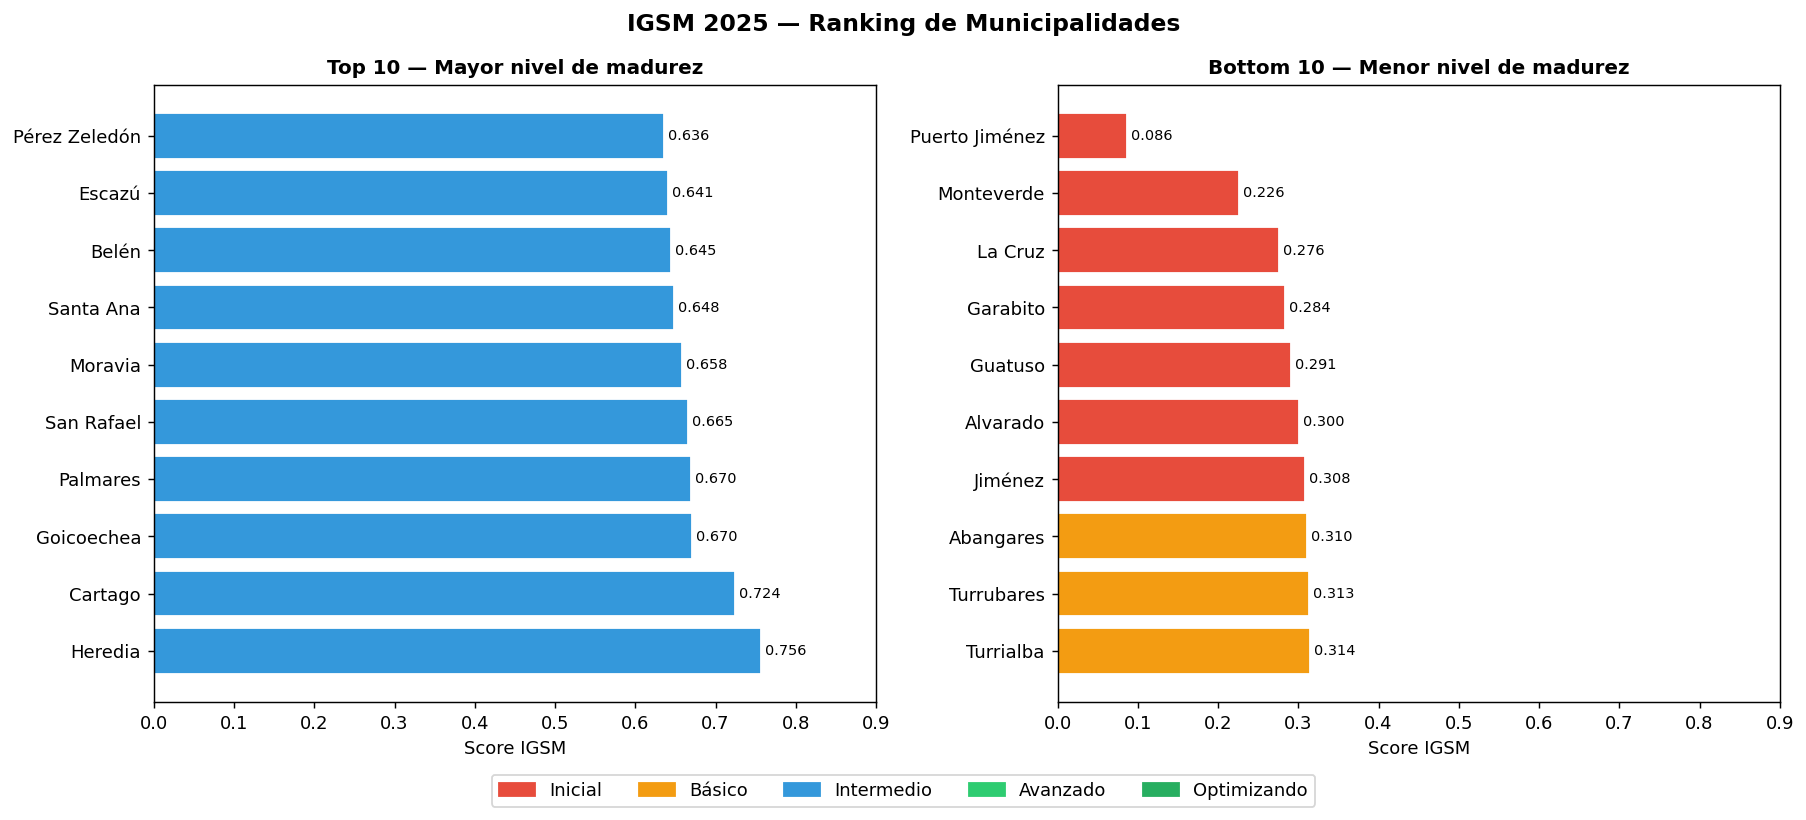

Figura 4 guardada ✓


In [11]:
# ── Figura 4: Top 10 y Bottom 10 municipalidades ─────────────────────────────
df_sorted = df_results.sort_values('score_total', ascending=False)
top10    = df_sorted.head(10)
bottom10 = df_sorted.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, titulo in [
    (axes[0], top10,    'Top 10 — Mayor nivel de madurez'),
    (axes[1], bottom10, 'Bottom 10 — Menor nivel de madurez'),
]:
    colores = [COLORS.get(n, '#95a5a6') for n in data['nivel_calculado']]
    ax.barh(data['municipalidad'], data['score_total'], color=colores, edgecolor='white')
    ax.set_xlabel('Score IGSM')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlim(0, 0.9)
    for i, (_, row) in enumerate(data.iterrows()):
        ax.text(row['score_total'] + 0.005, i, f"{row['score_total']:.3f}", va='center', fontsize=8)

# Leyenda de niveles
patches = [mpatches.Patch(color=c, label=n) for n, c in COLORS.items()]
fig.legend(handles=patches, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('IGSM 2025 — Ranking de Municipalidades', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_ranking.png', bbox_inches='tight')
plt.show()
print("Figura 4 guardada ✓")

## 8. Resumen ejecutivo

In [12]:
# ── Resumen estadístico ───────────────────────────────────────────────────────
print("=" * 60)
print("RESUMEN IGSM 2025 — Replicación Python")
print("=" * 60)
print(f"\nMunicipalidades evaluadas: {N}")
print(f"Score promedio nacional:   {df_results['score_total'].mean():.4f}")
print(f"Score máximo:              {df_results['score_total'].max():.4f} ({df_results.loc[df_results['score_total'].idxmax(), 'municipalidad']})")
print(f"Score mínimo:              {df_results['score_total'].min():.4f} ({df_results.loc[df_results['score_total'].idxmin(), 'municipalidad']})")

print("\n── Distribución por nivel ──")
for nivel in ['Inicial', 'Básico', 'Intermedio', 'Avanzado', 'Optimizando']:
    n = (df_results['nivel_calculado'] == nivel).sum()
    pct = n / N * 100
    bar = '█' * int(pct / 2)
    print(f"  {nivel:15s}: {n:2d} ({pct:4.1f}%) {bar}")

print(f"\n── Exactitud replicación vs CGR: {exactitud:.1f}% ──")
print("\nServicios con mayor score promedio:")
print(pd.Series({k: round(v,3) for k,v in prom_servicios.items()}).sort_values(ascending=False))

RESUMEN IGSM 2025 — Replicación Python

Municipalidades evaluadas: 84
Score promedio nacional:   0.4596
Score máximo:              0.7564 (Heredia)
Score mínimo:              0.0860 (Puerto Jiménez)

── Distribución por nivel ──
  Inicial        :  7 ( 8.3%) ████
  Básico         : 57 (67.9%) █████████████████████████████████
  Intermedio     : 20 (23.8%) ███████████
  Avanzado       :  0 ( 0.0%) 
  Optimizando    :  0 ( 0.0%) 

── Exactitud replicación vs CGR: 100.0% ──

Servicios con mayor score promedio:
Serv. Sociales      0.568
Urbanismo           0.518
Educ. Culturales    0.468
Residuos            0.432
Agua Potable        0.414
Seguridad           0.381
Red Vial            0.346
ZMT                 0.320
Aseo de Vías        0.250
Alcantarillado      0.240
dtype: float64


## 9. Hallazgos clave para la presentación

### Hallazgo 1 — Predominio de niveles bajos
El 76% de las municipalidades se concentra en los niveles **Inicial** y **Básico**, indicando que la mayor parte del país gestiona sus servicios de forma reactiva o con procesos frágiles sin estandarización.

### Hallazgo 2 — Brecha Planificación vs. Ejecución
El sistema pondera la Planificación al 50%. Aun así, el score de Ejecución es sistemáticamente inferior al de Planificación en todos los servicios básicos. Esto evidencia que tener documentos de planificación **no garantiza** que los servicios se ejecuten correctamente.

### Hallazgo 3 — Dispersión geográfica
Los servicios diversificados concentran las mayores brechas: municipalidades costeras con Alcantarillado Pluvial muestran los scores más bajos del sistema, mientras que grandes cantones urbanos como Cartago, Belén y Desamparados lideran el ranking.

### Limitación metodológica central
Los datos son **autoreportados** por las propias municipalidades sin verificación universal externa. El sistema puede registrar altos scores de Planificación aun cuando la ejecución presupuestaria sea del 71% en promedio.
